In [1]:
import sys
from pathlib import Path
notebook_dir = Path().resolve()
ROOT = notebook_dir.parent
sys.path.append(str(ROOT))

import networkx as nx 
import torch
from node2vec import Node2Vec
from src.methods.posEnc import LaplacianPosEnc
from torch_geometric.datasets import Amazon
from src.models.mlp import MLP
from src.plotting import visualize_embeddings
from src.models.svm import evaluate_with_svm
import matplotlib.pyplot as plt

dataset = Amazon(root='/Users/emely/Uni/Thesis/Thesis/data', name='Computers')
data = dataset[0]
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
data = data.to(device)
print(data)
from torch_geometric.utils import degree
num_nodes = data.num_nodes 

train_ratio = 0.8 
val_ratio = 0.1
test_ratio = 0.1

perm = torch.randperm(num_nodes)
train_idx = perm[:int(train_ratio * num_nodes)]
val_idx = perm[int(train_ratio * num_nodes):int((train_ratio+val_ratio) * num_nodes)]
test_idx = perm[int((train_ratio+val_ratio) * num_nodes):]

data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.train_mask[train_idx] = True

data.val_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.val_mask[val_idx] = True

data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.test_mask[test_idx] = True

deg = degree(data.edge_index[0], num_nodes=data.num_nodes)
print(f"Avg Degree: {deg.mean().item():.2f}")


Data(x=[13752, 767], edge_index=[2, 491722], y=[13752])
PubMed - Avg Degree: 35.76


In [ ]:
# node2vec

G = nx.Graph()

G.add_nodes_from(range(data.num_nodes))
G.add_edges_from(data.edge_index.t().tolist())

node2vec = Node2Vec(G, 
            dimensions=64,
            walk_length=50, 
            num_walks=30,
            p = 1.0, 
            q = 0.5,
            workers=5)

model = node2vec.fit(window = 10, min_count=1, batch_words=5)
emb_node2vec = torch.tensor([model.wv[str(n)] for n in range(data.num_nodes)])

print(emb_node2vec.shape) 

Computing transition probabilities:   0%|          | 0/13752 [00:00<?, ?it/s]

In [ ]:
# posEnc

pos_enc = LaplacianPosEnc(k=32)
data_posEnc = pos_enc(data)
emb_posEnc = data_posEnc.x

print(emb_posEnc.shape)

torch.Size([13752, 799])


In [ ]:
# original features
emb_original = data.x.clone().to(device)

tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  9.0838e-05,
          3.6086e-06, -3.7850e-05],
        [ 1.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  9.3772e-04,
          5.7621e-04,  1.2915e-03],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -4.3931e-04,
          4.8508e-05, -1.2230e-03],
        ...,
        [ 1.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  1.3617e-03,
          8.8801e-05,  6.7884e-04],
        [ 1.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  7.1586e-05,
          1.2737e-04, -1.9367e-04],
        [ 1.0000e+00,  1.0000e+00,  0.0000e+00,  ..., -3.9934e-04,
         -3.1444e-05, -7.3669e-04]], device='mps:0')


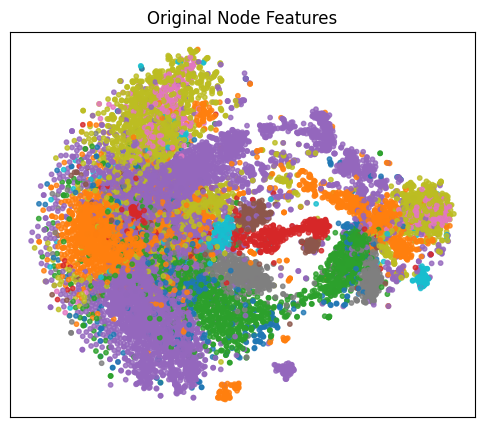

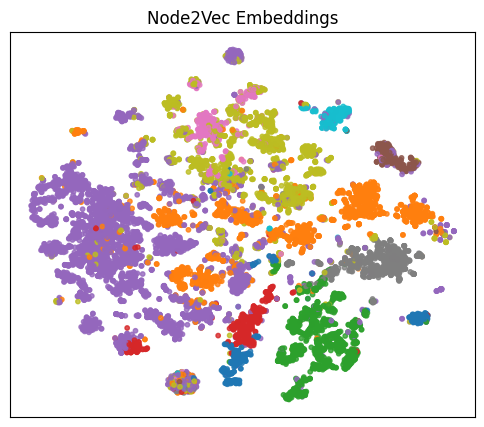

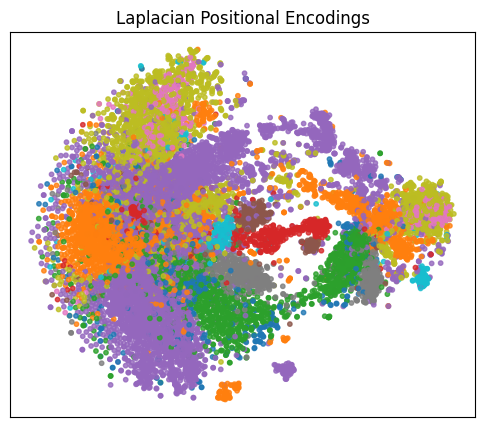

In [ ]:
labels = data.y

visualize_embeddings(emb_original,labels,title= "Original Node Features")
visualize_embeddings(emb_node2vec,labels,title= "Node2Vec Embeddings")
visualize_embeddings(emb_posEnc,labels,title= "Laplacian Positional Encodings")



MLP on NODE2VEC embeddings
[NODE2VEC] h1=128, h2=128, d=0.0, lr=0.0005, wd=1e-05 | Val 0.8909
[NODE2VEC] h1=128, h2=128, d=0.0, lr=0.0005, wd=0.0001 | Val 0.8931
[NODE2VEC] h1=128, h2=128, d=0.0, lr=0.0005, wd=0.0005 | Val 0.8895
[NODE2VEC] h1=128, h2=128, d=0.0, lr=0.001, wd=1e-05 | Val 0.9069
[NODE2VEC] h1=128, h2=128, d=0.0, lr=0.001, wd=0.0001 | Val 0.9069
[NODE2VEC] h1=128, h2=128, d=0.0, lr=0.001, wd=0.0005 | Val 0.9062
[NODE2VEC] h1=128, h2=128, d=0.0, lr=0.002, wd=1e-05 | Val 0.9127
[NODE2VEC] h1=128, h2=128, d=0.0, lr=0.002, wd=0.0001 | Val 0.9120
[NODE2VEC] h1=128, h2=128, d=0.0, lr=0.002, wd=0.0005 | Val 0.9069
[NODE2VEC] h1=128, h2=128, d=0.1, lr=0.0005, wd=1e-05 | Val 0.8880
[NODE2VEC] h1=128, h2=128, d=0.1, lr=0.0005, wd=0.0001 | Val 0.8924
[NODE2VEC] h1=128, h2=128, d=0.1, lr=0.0005, wd=0.0005 | Val 0.8953
[NODE2VEC] h1=128, h2=128, d=0.1, lr=0.001, wd=1e-05 | Val 0.9076
[NODE2VEC] h1=128, h2=128, d=0.1, lr=0.001, wd=0.0001 | Val 0.9033
[NODE2VEC] h1=128, h2=128, d=0.1,

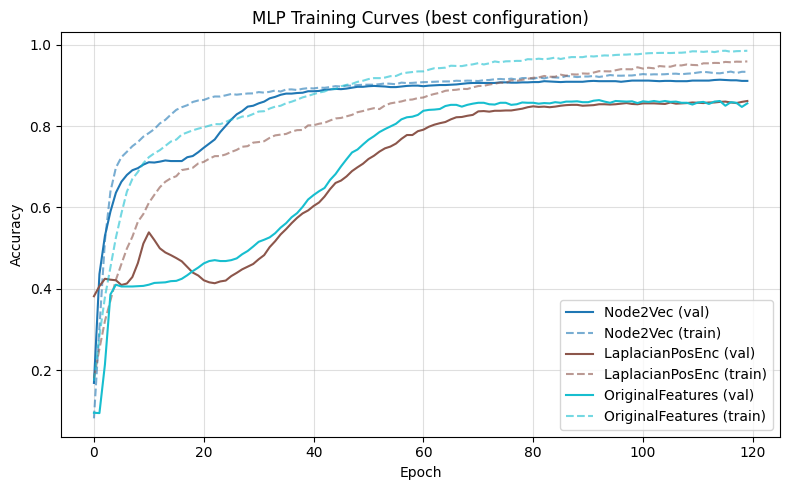

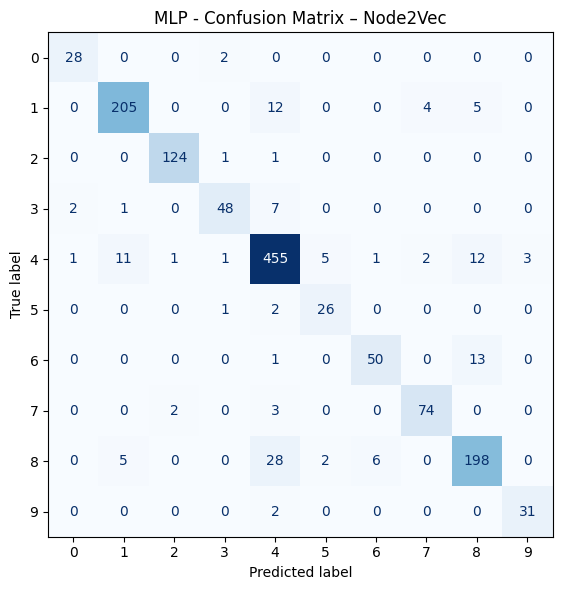

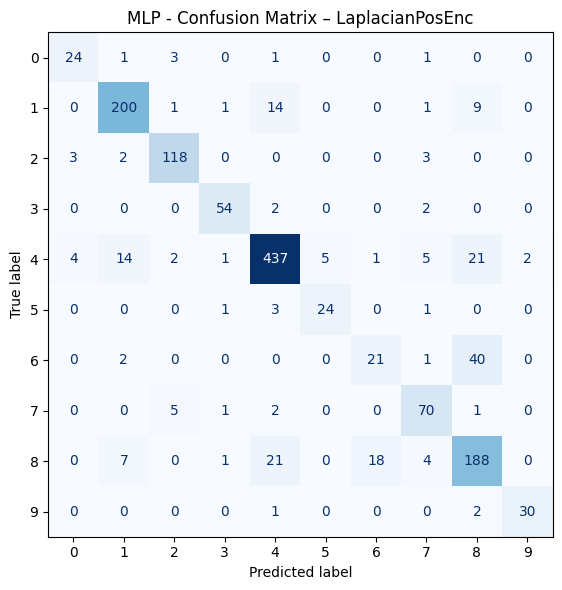

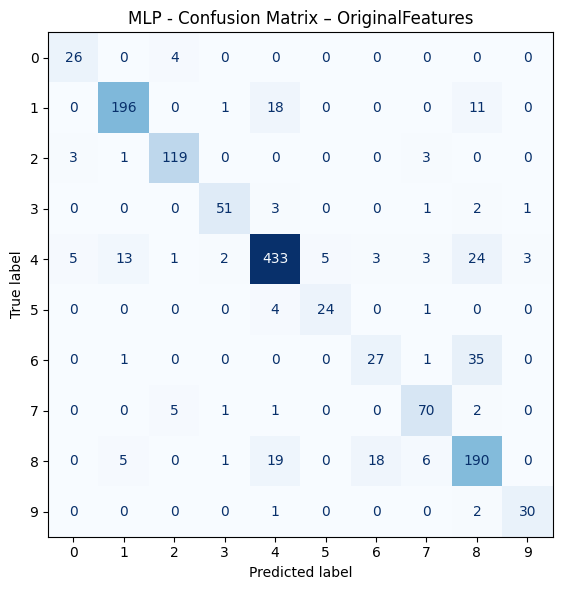

In [ ]:
# evaluation with MLP
# saving results

results_dir = Path("/Users/emely/Uni/Thesis/Thesis/amazon/results")
results_dir.mkdir(parents=True, exist_ok=True)

embeddings = {"LaplacianPosEnc": emb_posEnc, "Node2Vec": emb_node2vec, "OriginalFeatures": emb_original}

best_results, best_acc = MLP.evaluate_with_mlp(
    embeddings=embeddings,
    data=data,
    device=device,
    mlp_epochs=120
)

torch.save(best_acc, results_dir / "best_acc_node_pos.pt")
emb_file = Path("/Users/emely/Uni/Thesis/Thesis/amazon/results/embeddings.pt")

if emb_file.exists():
    all_embeddings = torch.load(emb_file)
else:
    all_embeddings = {}

for name, emb_tensor in embeddings.items():
    all_embeddings[name] = {name: emb_tensor.detach().cpu()}

torch.save(all_embeddings, emb_file)

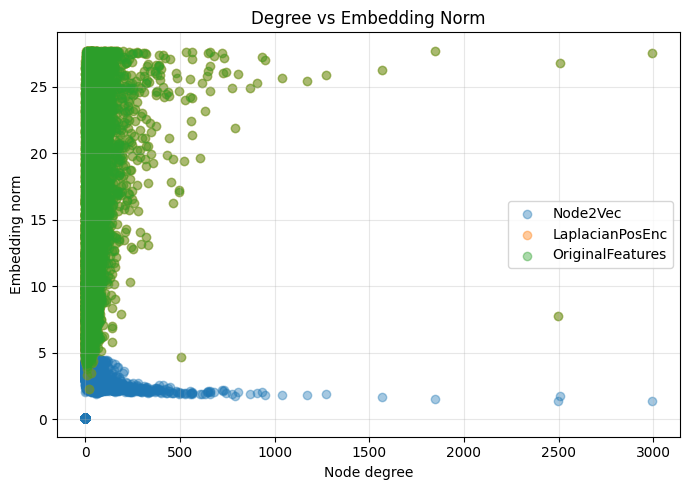

In [ ]:
degrees = torch.tensor([G.degree(n) for n in range(data.num_nodes)])

plt.figure(figsize=(7, 5))

for name, emb in embeddings.items():
    norms = emb.norm(dim=1).cpu() 
    plt.scatter(degrees, norms, alpha=0.4, label=name)

plt.xlabel("Node degree")
plt.ylabel("Embedding norm")
plt.title("Degree vs Embedding Norm")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



SVM on NODE2VEC embeddings
C=0.01 | Val Acc=0.8393
C=0.1 | Val Acc=0.8596
C=1 | Val Acc=0.8669
C=10 | Val Acc=0.8669
Best C=1 | Test Acc=0.8517


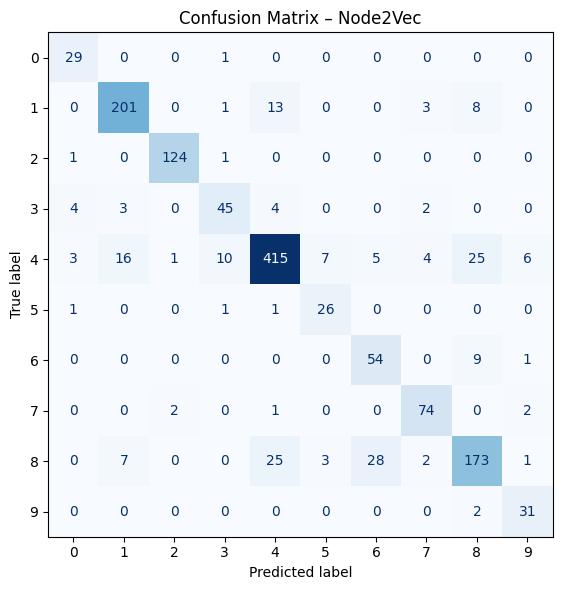


SVM on LAPLACIANPOSENC embeddings
C=0.01 | Val Acc=0.7993
C=0.1 | Val Acc=0.8407
C=1 | Val Acc=0.8487
C=10 | Val Acc=0.8284
Best C=1 | Test Acc=0.8307


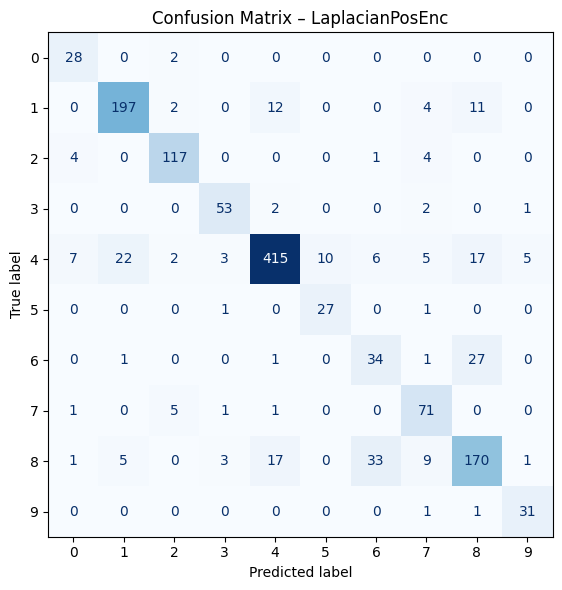


SVM on ORIGINALFEATURES embeddings
C=0.01 | Val Acc=0.7993
C=0.1 | Val Acc=0.8407
C=1 | Val Acc=0.8487
C=10 | Val Acc=0.8284
Best C=1 | Test Acc=0.8307


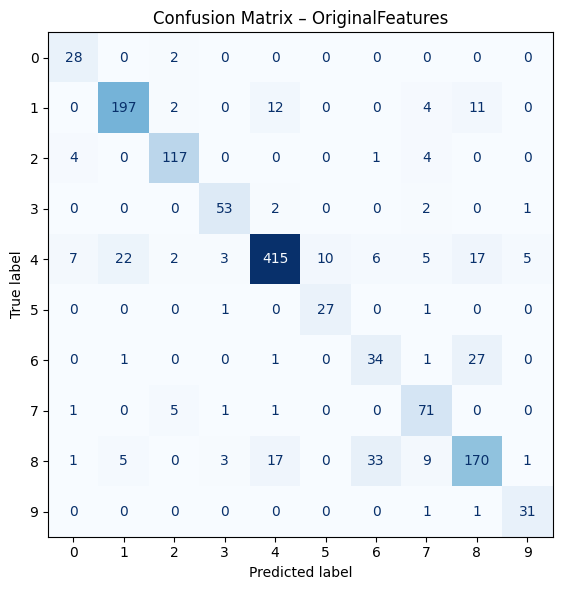

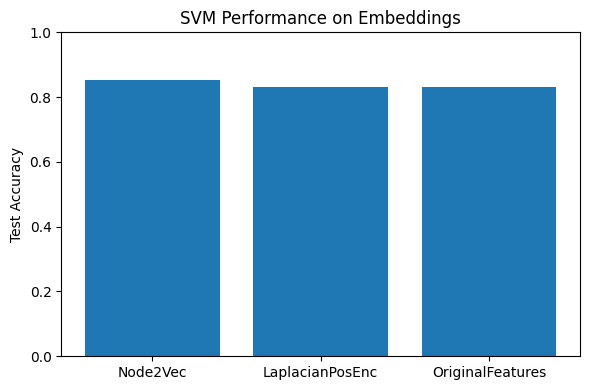

In [ ]:
# evaluate with SVM

svm_results = evaluate_with_svm(
    embeddings=embeddings,
    data=data,
    device=device
)
torch.save(svm_results,"/Users/emely/Uni/Thesis/Thesis/amazon/results/svm_results_node_pos.pt")